#IDENTIFIKASI MASALAH & SOLUSI

##Identifikasi Masalah
Fenomena investasi pasar modal di kalangan generasi muda saat ini rentan memicu kerugian finansial karena sering kali didorong oleh keputusan emosional akibat Fear of Missing Out (FOMO) tanpa pemahaman analitis terhadap dinamika dan risiko pasar. Untuk menjawab tantangan mengenai bagaimana memberikan insight investasi yang objektif dan berbasis data demi mencegah kerugian tersebut, proyek ini mengusulkan AI-based Portfolio Analyzer sebagai solusi painkiller. Sistem ini berfokus pada penentuan indikator kesiapan investasi melalui pembentukan profil risiko pengguna, serta penyediaan analisis tren pergerakan saham mendalam tanpa memberikan rekomendasi eksekusi beli/jual secara langsung. Guna memastikan keandalan sistem secara teknis, riset dalam proyek ini difokuskan untuk mengevaluasi seberapa efektif model K-Means Clustering dalam mengidentifikasi dan mengelompokkan profil risiko investor berdasarkan perilaku transaksinya, sekaligus menguji apakah implementasi arsitektur Deep Learning (TensorFlow) mampu memprediksi tren volatilitas portofolio dengan tingkat akurasi Mean Absolute Error (MAE) di bawah 0.02.

**💡 Solusi**

Untuk menjawab kedua masalah tersebut, analisis ini berfokus pada dua pendekatan:

1. **Pemetaan Profil Risiko Berbasis Data (Risk/Volatility Scoring)**
   Menghitung volatilitas return harian saham-saham LQ45 dan menetapkan batas
   klasifikasi risiko secara data-driven menggunakan nilai kuantil (Q33 & Q66),
   sehingga setiap saham dapat dikategorikan secara otomatis ke dalam kelompok
   **Low**, **Medium**, atau **High Risk**.

2. **Kuantifikasi Risiko dalam Nominal Rupiah (Personalized VaR)**
   Menghitung Value at Risk (VaR) menggunakan metode Cornish-Fisher yang
   mempertimbangkan karakteristik distribusi return non-normal (skewness & kurtosis),
   kemudian menerjemahkan nilai risiko tersebut ke dalam nominal rupiah berdasarkan
   modal awal pengguna — sehingga risiko menjadi lebih nyata dan mudah dipahami.

#PERTANYAAN BISNIS

**Pertanyaan Bisnis**
1. Bagaiman karakteristik tren pergerakan harga dan volalitas saham LQ45, serta bagaimana metrik tersebut digunakan untuk mendefinisikan batas profil risiko (Low, Medium, High) secara data-driven?
2. Berapa estimasi potensi kerugian maksimum (Value at Risk / VaR) dari saham yang dipilih pengguna, dan bagaimana nilai tersebut dipersonalisasi berdasarkan input modal awal mereka?

**Analytical Questions**
1. Berapa return harian masing-masing saham LQ45?
2. Bagaimana distribusi dan tren pergerakan harga tiap saham?
3. Seberapa tinggi volalitas (std. dev return) masing-masing saham?
4. Bagaimana klasifikasi saham dalam kelompok Low, Medium, atau High risk?
5. Berapa nilai VaR masing masing saham pada tingkat kepercayaan 95%>
6. Berapa potensi kerugian maksimum dalam nominal Rupiah berdasarkan modal awal yang diinput pengguna?

additional
bagaimana distribusi return tiap saham, berapa nilai skewness dan kurtosis return tiap saham


# INFORMASI DATASET

##Data Historis :
* **Sumber Data:** API Yahoo Finance (`yfinance`).
* **Karakteristik:** Data deret waktu (*time-series*) yang ditarik secara *real-time* atau historis berdasarkan rentang waktu tertentu.
* **Fitur Utama (Kolom):** `Date`, `Open`, `High`, `Low`, `Close`, `Volume`.
* **Tujuan Penggunaan:** Digunakan oleh tim Data Science untuk menghitung indikator teknikal (EDA & Volatilitas/Risiko) dan oleh tim AI untuk melatih model *Deep Learning* (LSTM/GRU) dalam melakukan *Stock Forecasting*.

# IMPORT LIBRARY/PACKAGES YANG DIGUNAKAN

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#DATA WRANGLING

## Gathering Data
Pengumpulkan data historis harga saham LQ45 dari API yfinance

In [ ]:
lq45_union = sorted([
        "AALI.JK", "ACES.JK", "ADHI.JK", "ADRO.JK", "AKRA.JK",
        "AMMN.JK", "AMRT.JK", "ANTM.JK", "ARTO.JK", "ASII.JK",
        "BBCA.JK", "BBNI.JK", "BBRI.JK", "BBTN.JK", "BFIN.JK",
        "BJBR.JK", "BKSL.JK", "BMRI.JK", "BMTR.JK", "BRIS.JK",
        "BRPT.JK", "BSDE.JK", "BTPS.JK", "BUKA.JK", "BUMI.JK",
        "CPIN.JK", "CTRA.JK", "ELSA.JK", "EMTK.JK", "ERAA.JK",
        "ESSA.JK", "EXCL.JK", "GGRM.JK", "GOTO.JK", "HMSP.JK",
        "HRUM.JK", "ICBP.JK", "INCO.JK", "INDF.JK", "INDY.JK",
        "INKP.JK", "INTP.JK", "ISAT.JK", "ITMG.JK", "JPFA.JK",
        "JSMR.JK", "KLBF.JK", "LPKR.JK", "LPPF.JK", "LSIP.JK",
        "MAPI.JK", "MBMA.JK", "MDKA.JK", "MEDC.JK", "MIKA.JK",
        "MNCN.JK", "MTEL.JK", "MYRX.JK", "PGAS.JK", "PGEO.JK",
        "PPRO.JK", "PTBA.JK", "PTMP.JK", "PTPP.JK", "PWON.JK",
        "SCMA.JK", "SIDO.JK", "SMGR.JK", "SMRA.JK", "SRIL.JK",
        "SRTG.JK", "SSMS.JK", "TBIG.JK", "TINS.JK", "TKIM.JK",
        "TLKM.JK", "TOWR.JK", "TPIA.JK", "TRAM.JK", "UNTR.JK",
        "UNVR.JK", "WIKA.JK", "WSBP.JK", "WSKT.JK"
    ])


all_data = []

for ticker in lq45_union:

  try:
    data = yf.download(
        ticker,
        start="2015-01-01",
        end="2026-01-01",
        progress=False,
        auto_adjust=True,
    )
    if isinstance(data.columns, pd.MultiIndex):
      data.columns = data.columns.to_flat_index()
      data.columns = [col[0] for col in data.columns]

    data['Ticker'] = ticker
    all_data.append(data)
  except Exception as e:
    print(f"Error fetching data for {ticker}: {e}")

In [ ]:
stocks_df = pd.concat(all_data)

In [ ]:
stocks_df = stocks_df.reset_index()

In [ ]:
stocks_df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2015-01-02,16222.208984,16502.755309,16007.672366,16040.677895,1385945,AALI.JK
1,2015-01-05,16288.220703,16304.722792,16073.684076,16238.711730,619089,AALI.JK
2,2015-01-06,16040.675781,16222.206846,15958.162645,16222.206846,1142676,AALI.JK
3,2015-01-07,16304.717773,16304.717773,16040.673608,16040.673608,1882560,AALI.JK
4,2015-01-08,16651.279297,16750.295876,16403.737172,16403.737172,1504852,AALI.JK


In [ ]:
stocks_df.to_csv('lq45_raw_data_2015_2025.csv', index=False)

## Assessing Data

In [ ]:
# Cek struktur dataset
stocks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211464 entries, 0 to 211463
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    211464 non-null  datetime64[ns]
 1   Close   211464 non-null  float64       
 2   High    211464 non-null  float64       
 3   Low     211464 non-null  float64       
 4   Open    211464 non-null  float64       
 5   Volume  211464 non-null  int64         
 6   Ticker  211464 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 11.3+ MB


In [ ]:
# Cek ukuran dataset
print(f"Shape data: {stocks_df.shape}")

Shape data: (211464, 7)


In [ ]:
# Cek jumlah saham unik
print(stocks_df["Ticker"].nunique())
print(sorted(stocks_df["Ticker"].unique()))

84
['AALI.JK', 'ACES.JK', 'ADHI.JK', 'ADRO.JK', 'AKRA.JK', 'AMMN.JK', 'AMRT.JK', 'ANTM.JK', 'ARTO.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BBTN.JK', 'BFIN.JK', 'BJBR.JK', 'BKSL.JK', 'BMRI.JK', 'BMTR.JK', 'BRIS.JK', 'BRPT.JK', 'BSDE.JK', 'BTPS.JK', 'BUKA.JK', 'BUMI.JK', 'CPIN.JK', 'CTRA.JK', 'ELSA.JK', 'EMTK.JK', 'ERAA.JK', 'ESSA.JK', 'EXCL.JK', 'GGRM.JK', 'GOTO.JK', 'HMSP.JK', 'HRUM.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK', 'INDY.JK', 'INKP.JK', 'INTP.JK', 'ISAT.JK', 'ITMG.JK', 'JPFA.JK', 'JSMR.JK', 'KLBF.JK', 'LPKR.JK', 'LPPF.JK', 'LSIP.JK', 'MAPI.JK', 'MBMA.JK', 'MDKA.JK', 'MEDC.JK', 'MIKA.JK', 'MNCN.JK', 'MTEL.JK', 'MYRX.JK', 'PGAS.JK', 'PGEO.JK', 'PPRO.JK', 'PTBA.JK', 'PTMP.JK', 'PTPP.JK', 'PWON.JK', 'SCMA.JK', 'SIDO.JK', 'SMGR.JK', 'SMRA.JK', 'SRIL.JK', 'SRTG.JK', 'SSMS.JK', 'TBIG.JK', 'TINS.JK', 'TKIM.JK', 'TLKM.JK', 'TOWR.JK', 'TPIA.JK', 'TRAM.JK', 'UNTR.JK', 'UNVR.JK', 'WIKA.JK', 'WSBP.JK', 'WSKT.JK']


In [ ]:
# Cek missing values
stocks_df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
Ticker,0


In [ ]:
# Cek duplicate data
print("Jumlah duplikasi:", stocks_df.duplicated().sum())

Jumlah duplikasi: 0


In [ ]:
# Cek rentang tanggal
stocks_df["Date"].min(), stocks_df["Date"].max()

(Timestamp('2015-01-02 00:00:00'), Timestamp('2025-12-30 00:00:00'))

In [ ]:
# Cek jumlah data per saham
stocks_df["Ticker"].value_counts()

,count
Ticker,
AALI.JK,2711
ADHI.JK,2711
AMRT.JK,2711
AKRA.JK,2711
BKSL.JK,2711
...,...
GOTO.JK,891
PGEO.JK,674
PTMP.JK,668


In [ ]:
# Cek apakah ada harga negatif atau nol
# Harga saham mencerminkan nilai kepemilikan suatu perusahaan
print("Jumlah harga negatif:", (stocks_df["Close"] <= 0).sum())
print("Jumlah harga nol:", (stocks_df["Close"] == 0).sum())


Jumlah harga negatif: 0
Jumlah harga nol: 0


In [ ]:
# Cek apakah jumlah lembar saham yang diperdagangkan (volume) negatif
print("Jumlah volume negatif:", (stocks_df["Volume"] < 0).sum())

Jumlah volume negatif: 0


In [ ]:
# Cek saham dengan data paling sedikit
stocks_df["Ticker"].value_counts().sort_values().head(10)

,count
Ticker,
AMMN.JK,594
MBMA.JK,640
PTMP.JK,668
PGEO.JK,674
GOTO.JK,891
MTEL.JK,987
BUKA.JK,1060
BRIS.JK,1873
BTPS.JK,1873


In [ ]:
# Cek saham dengan volume 0 terbanyak
(
    stocks_df[stocks_df["Volume"] == 0]
    ["Ticker"]
    .value_counts()
)

,count
Ticker,
BKSL.JK,1604
TRAM.JK,1526
MYRX.JK,1394
SRIL.JK,1182
WSKT.JK,715
...,...
GOTO.JK,3
MBMA.JK,3
PTMP.JK,3


In [ ]:
# Cek missing trading days
print("Jumlah trading days yang hilang:", (stocks_df["Volume"] == 0).sum())
stocks_df.groupby("Ticker")["Date"].count()

Jumlah trading days yang hilang: 14080


,Date
Ticker,
AALI.JK,2711
ACES.JK,2710
ADHI.JK,2711
ADRO.JK,2710
AKRA.JK,2711
...,...
UNTR.JK,2710
UNVR.JK,2711
WIKA.JK,2710


In [ ]:
# Statistical summary
stocks_df.describe()

,Date,Close,High,Low,Open,Volume
count,211464,211464.000000,211464.000000,211464.000000,211464.000000,2.114640e+05
mean,2020-08-03 10:53:23.268640768,2734.565204,2776.854284,2696.190035,2738.214336,6.796816e+07
min,2015-01-02 00:00:00,7.000000,7.000000,7.000000,7.000000,0.000000e+00
25%,2017-11-22 00:00:00,471.113434,480.411231,463.089203,472.000000,4.348550e+06
50%,2020-08-04 00:00:00,1111.424316,1132.353846,1094.373219,1113.998924,1.552310e+07
75%,2023-05-08 00:00:00,2645.902344,2691.998005,2602.662814,2650.868793,4.447680e+07
max,2025-12-30 00:00:00,71802.335938,76803.399060,70433.223600,71726.266826,6.601081e+10
std,NaN,5219.845412,5287.660528,5156.708878,5224.503774,4.263698e+08


###**Insight**

Berdasarkan proses assessing data, dataset saham yang digunakan memiliki 211.464 baris data dan 7 kolom. Dataset mencakup 84 saham unik dengan periode observasi dari Januari 2015 - Desember 2025. Secara umu, kualitas data tergolong baik karena:

* Tidak ditemukan missing values pada seluruh variabel.
* Tidak terdapat data duplikat.
* Tidak ditemukan harga saham bernilai negatif maupun nol.
* Seluruh volume transaksi juga tidak memiliki nilai negatif.

Namun, ditemukan beberapa hal penting dari proses assessing:

1. Jumlah observasi tiap saham tidak sama, beberapa saham memiliki data lebih sedikit dibanding saham lain, misalnya:
  * AMMN.JK
  * MBMA.JK
  * PTMP.JK
Sementara sebagian besar saham emmiliki jumlah observasi sekitar 2.700 data perdagangan. Perbedaan ini kemungkinan disebabkan beberapa saham baru IPO atau mulai diperdagangan pada periode tertentu sehingga data historisnya lebih pendek.
2. Terdapat volume transaksi bernilai nol. Total terdapat 14.080 trading days dengan volume transaksi nol. beberapa saham memilki jumlah nol cukup tinggi, seperti:
* BKSL.JK
* TRAM.JK
* MYRX.JK
Kondisi ini mengindikasikan adanya aktivitas perdagangan yang rendah, saham kurang likuid, suspensi perdagangan, atau saham tidak aktif diperdagangkan pada periode tertentu.
3. Distribusi harga saham cukup bervariasi, berdasarkan statistical summary:
* Harga penutupan minimum mencapai sebesar 7 rupiah
* Harga maksimum mencapai sekitar 71.802 rupiah
* Rata-rata harga penutupan sekitar 2.735 rupiah
Variasi harga yang cukup besar menunjukkan adanya perbedaan karakteristik dan kapitalisasi antar saham dalam dataset
4. Volume transaksi memiliki rentang yang sangat besar
Volume perdagangan maksimum mencapai lebih dari 66 miliar saham dalam satu hari perdagangan. Hal ini menunjukkan adanya perbedaan tingkat likuiditas antar saham, di mana beberapa saham sangat aktif diperdagangkan sementara saham lainnya memiliki aktivitas yang rendah.

Secara keseluruhan, dataset sudah cukup bersih dan layak digunakan untuk analisis time series maupun forecasting. Namun beberapa saham dengan jumlah volume nol yang tinggi perlu dipertimbangkan agar tidak memengaruhi kualitas analisis dan performa model.

## Cleaning Data

In [ ]:
clean_df = stocks_df.copy()

In [ ]:
# Fungsi informasi dataset
def dataset_summary(df):

    print("===== DATASET SUMMARY =====")
    print(f"Shape            : {df.shape}")
    print(f"Duplicate Rows   : {df.duplicated().sum()}")
    print(f"Missing Values   :\n{df.isnull().sum()}")

dataset_summary(clean_df)

===== DATASET SUMMARY =====
Shape            : (211464, 7)
Duplicate Rows   : 0
Missing Values   :
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64


In [ ]:
clean_df = clean_df.sort_values(
    by=["Ticker", "Date"]
).reset_index(drop=True)

In [ ]:
zero_volume = clean_df[
    clean_df["Volume"] == 0
]

zero_volume["Ticker"].value_counts()

,count
Ticker,
BKSL.JK,1604
TRAM.JK,1526
MYRX.JK,1394
SRIL.JK,1182
WSKT.JK,715
...,...
GOTO.JK,3
MBMA.JK,3
PTMP.JK,3


In [ ]:
zero_ratio = (
    clean_df.groupby("Ticker")["Volume"]
    .apply(lambda x: (x == 0).mean())
    .sort_values(ascending=False)
)

zero_ratio.head(10)

,Volume
Ticker,
BKSL.JK,0.591664
TRAM.JK,0.563100
MYRX.JK,0.535948
SRIL.JK,0.436001
WSKT.JK,0.263740
EMTK.JK,0.199926
WSBP.JK,0.147162
PPRO.JK,0.135703
WIKA.JK,0.130996


In [ ]:
# Menggunakan threshold
problematic_stocks = zero_ratio[
    zero_ratio > 0.2
].index

problematic_stocks

Index(['BKSL.JK', 'TRAM.JK', 'MYRX.JK', 'SRIL.JK', 'WSKT.JK'], dtype='object', name='Ticker')

In [ ]:
# Remove saham bermasalah
clean_df = clean_df[
    ~clean_df["Ticker"].isin(problematic_stocks)
]

In [ ]:
clean_df["Ticker"].nunique()

79

In [ ]:
clean_df.to_csv(
    "lq45_clean_dataset.csv",
    index=False
)

###**Insight**

Berdasarkan hasil cleaning yang dilakukan untuk menangani saham dengan aktivitas perdagangan yang rendah. Saham yang memiliki proporsi volume transaksi nol lebih dari 20%  dieliminasi dieliminasi dari dataset karena dianggap  kurang aktif diperdagangan dan berpotensi menghasilkan bias pada analisis.

Dari proses tersebut diperoleh beberapa saham yang dihapus, yaitu:
* TRAM.JK
* MYRX.JK
* SRIL.JK
* WSKT.JK
* BKSL.JK

Saham-saham tersebut memiliki jumlah trading days tanpa transaksi yang sangat tinggi sehingga kurang representatif untuk analisis pergerakan harga saham

Setelah proses filtering dilakukan:
* Jumlah saham berkurang dari 84 saham menjadi 79 saham
* Jumlah observasi data juga berkurang menyesuaikan dengan penghapusan saham yang tidak aktif.

Selanjutnya dilakukan pengecekan ulang terhadap kualitas data hasil cleaning dan diperoleh hasil bahwa:
* Tidak terdapat missing values
* Tidak terdapat data duplikat
* Tidak terdapat harga negatif maupun nol
* Tidak terdapat volume negatif

Secara keseluruhan, tahap cleaning berhasil meningkatkan kualitas dataset dengan menghapus saham yang tidak aktif diperdagangkan sehingga analisis forecasting dan perhitungan risiko dapat dilakukan dengan lebih akurat dan minim noise data.

#EDA

In [ ]:
# Konfigurasi tampilan visualisasi
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

###**1. Overview Dataset**

In [ ]:
# Menampilkan 5 data pertama
clean_df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2015-01-02,16222.208984,16502.755309,16007.672366,16040.677895,1385945,AALI.JK
1,2015-01-05,16288.220703,16304.722792,16073.684076,16238.711730,619089,AALI.JK
2,2015-01-06,16040.675781,16222.206846,15958.162645,16222.206846,1142676,AALI.JK
3,2015-01-07,16304.717773,16304.717773,16040.673608,16040.673608,1882560,AALI.JK
4,2015-01-08,16651.279297,16750.295876,16403.737172,16403.737172,1504852,AALI.JK


In [ ]:
# Melihat jumlah ticker saham unik
print(f"Jumlah saham unik: {clean_df['Ticker'].nunique()}")

Jumlah saham unik: 79


###**2. Analisis Periode Data**

In [ ]:
# Melihat rentang tanggal observasi
print(
    f"Periode data: "
    f"{clean_df['Date'].min()} "
    f"sampai "
    f"{clean_df['Date'].max()}"
)

Periode data: 2015-01-02 00:00:00 sampai 2025-12-30 00:00:00


###**3. Distribusi Jumlah Data per Saham**

In [ ]:
# Menghitung jumlah data per saham
stock_counts = (
    clean_df["Ticker"]
    .value_counts()
    .sort_values(ascending=False)
)

stock_counts.head(10)

,count
Ticker,
AALI.JK,2711
ADHI.JK,2711
AKRA.JK,2711
AMRT.JK,2711
BBRI.JK,2711
BBCA.JK,2711
ANTM.JK,2711
BBTN.JK,2711
BFIN.JK,2711


###**4. Visualisasi Harga Penutupan Saham**

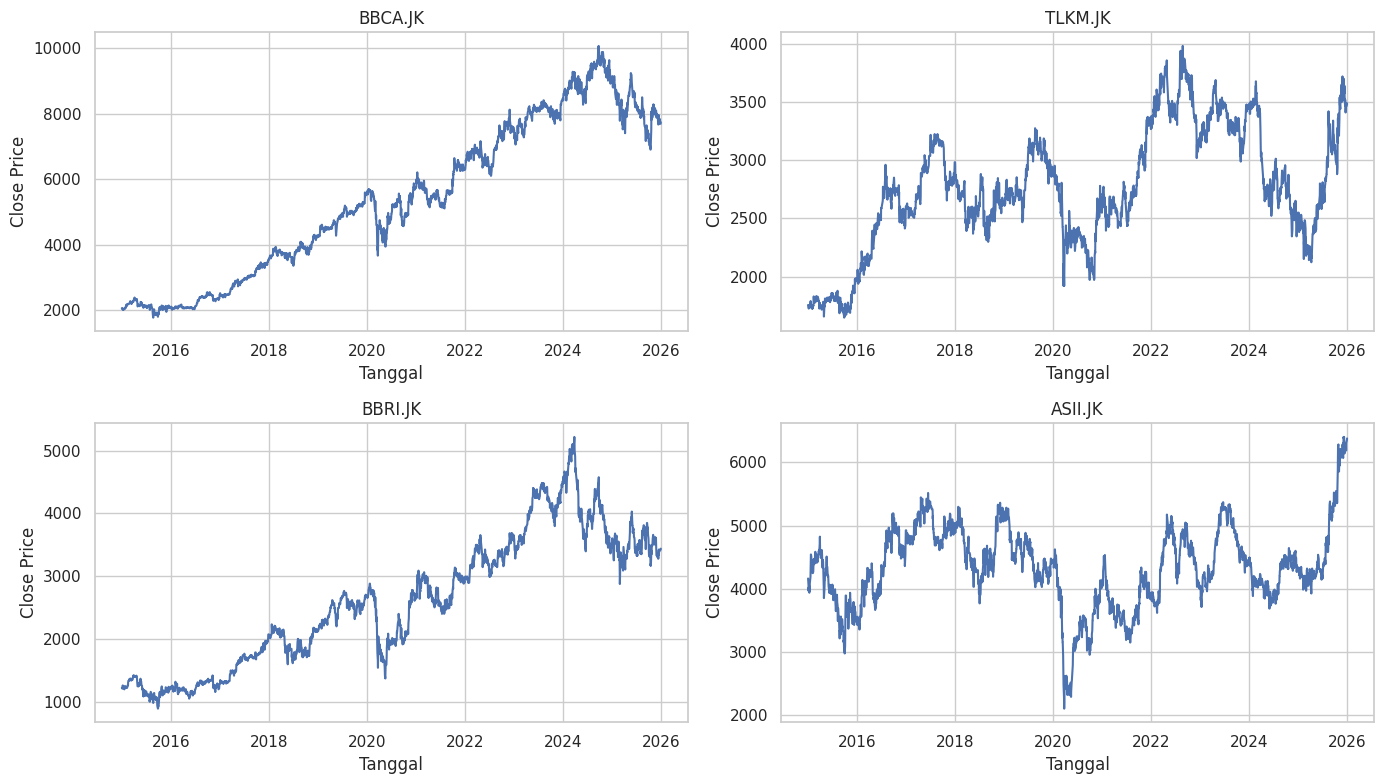

In [ ]:
# Daftar saham yang ingin divisualisasikan
selected_stocks = [
    "BBCA.JK",
    "TLKM.JK",
    "BBRI.JK",
    "ASII.JK"
]

# Membuat grid subplot 2x2
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 8)
)

# Flatten axes agar mudah di-loop
axes = axes.flatten()

# Loop tiap saham
for i, ticker in enumerate(selected_stocks):

    # Filter data saham
    stock_data = clean_df[
        clean_df["Ticker"] == ticker
    ]

    # Plot harga penutupan
    axes[i].plot(
        stock_data["Date"],
        stock_data["Close"]
    )

    # Judul subplot
    axes[i].set_title(f"{ticker}")

    # Label sumbu
    axes[i].set_xlabel("Tanggal")
    axes[i].set_ylabel("Close Price")

# Mengatur layout agar rapi
plt.tight_layout()

# Menampilkan visualisasi
plt.show()

Berdasarkan output di atas, keempat saham mengalami penurunan tajam di 2020 (COVID-19) lalu rebound kuat. Sektor perbangkan (BBCA,BBRI) mencatat pertumbuhan jangka panjang paling signifikan, sementara TLKM dan ASII cenderung sideways tanpa tren naik yang jelas. BBCA menjadi saham paling stabil dan konsisten pertumbuhannya.

###**5. Distribusi Volume Transaksi**

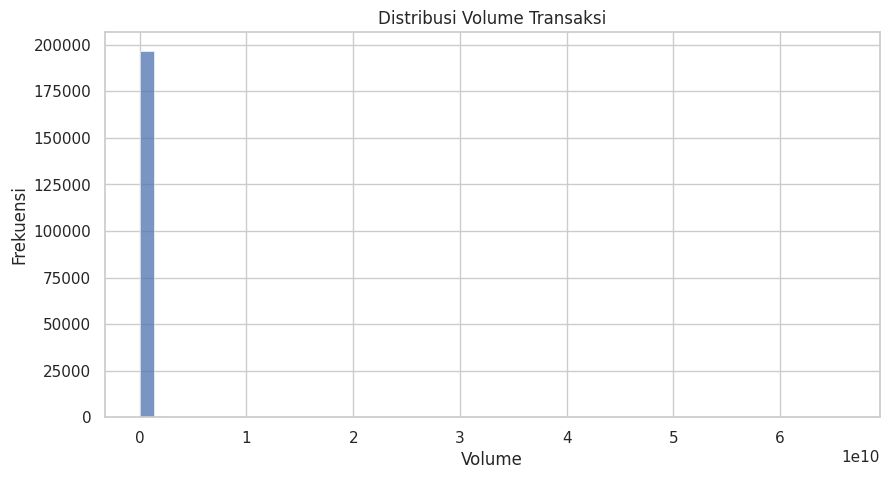

In [ ]:
# Visualisasi distribusi volume transaksi
plt.figure(figsize=(10, 5))

sns.histplot(
    clean_df["Volume"],
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.4,
    bins=50
)

plt.title("Distribusi Volume Transaksi")
plt.xlabel("Volume")
plt.ylabel("Frekuensi")

plt.show()

Berdasarkan output tersebut, grafik menunjukkan bahwa data sangat skewed ke kanan (right-skewed). Sebagian besar volume transaksi berada pada nilai rendah, sementara beberapa saham memiliki volume transaksi yang sangat tinggi sehingga mendominasi distribusi.

Akibatnya, pola distribusi utama sulit terlihat dengan jelas karena data menumpuk pada sisi kiri grafik. Oleh karena itu, transformasi log scale dilakukan untuk mengarungi pengaruh outlier ekstrem dan membuat distribusi data lebih mudah dianalisis.

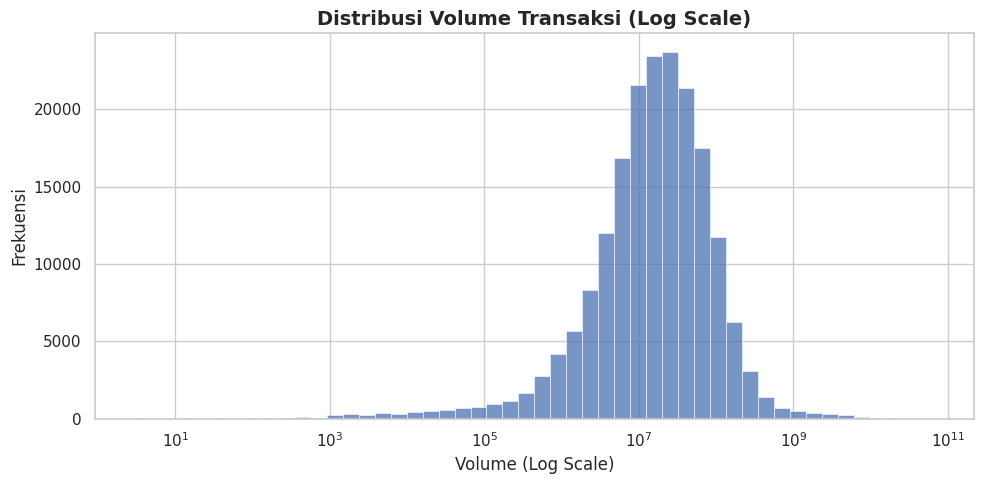

In [ ]:
   # Melihat persebaran volume perdagangan
plt.figure(figsize=(10, 5))

sns.histplot(
    clean_df["Volume"],
    bins=50,
    log_scale=True,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.4
)

plt.title("Distribusi Volume Transaksi (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Volume (Log Scale)")
plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()

Berdasarkan output tersebut, grafik menunjukkan pola distribusi yang jauh lebih jelas dibandingkan histogram sebelumnya (mengikuti distribusi normal). Sebagian besar volume transaksi saham berada pada rentang menengah, sementara hanya sedikit observasi yang memiliki volume transaksi sangat rendah maupun sangat tinggi.

/tmp/ipykernel_23980/4062849457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


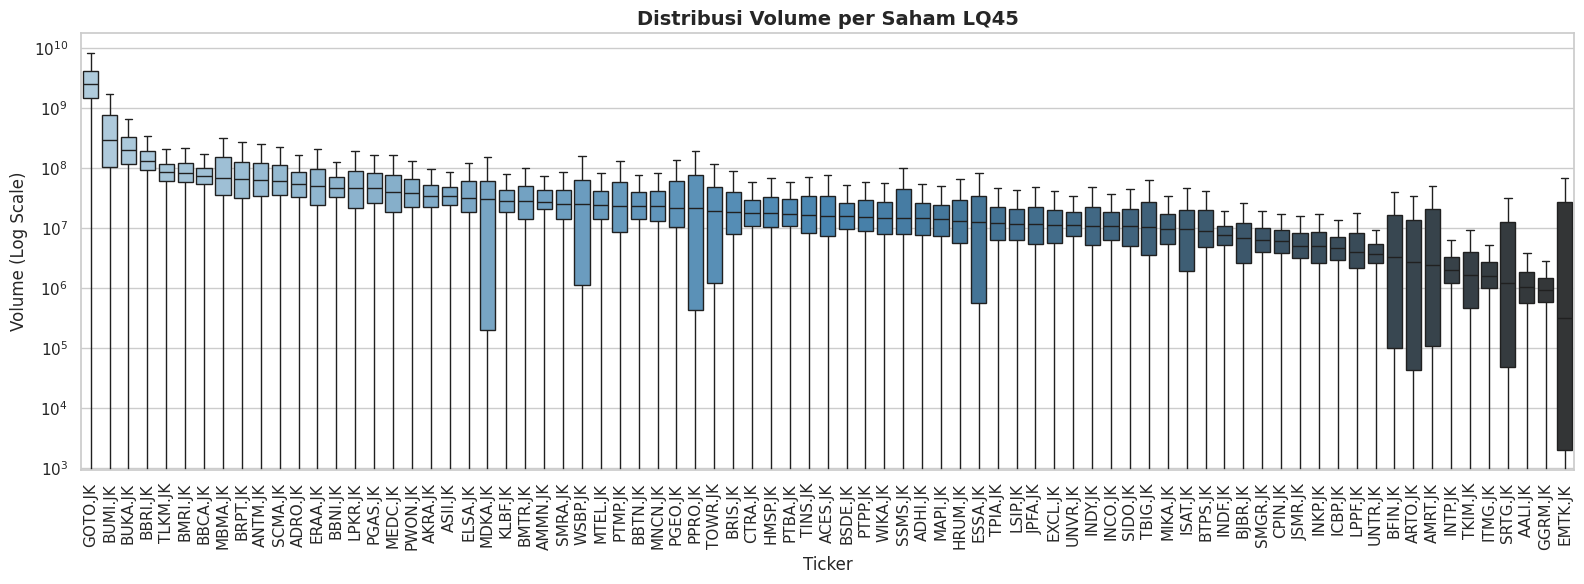

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

# Ambil median volume per ticker untuk sorting
order = (clean_df.groupby("Ticker")["Volume"]
         .median()
         .sort_values(ascending=False)
         .index)

sns.boxplot(
    data=clean_df,
    x="Ticker", y="Volume",
    order=order,
    showfliers=False,      # sembunyikan outlier agar tidak berantakan
    palette="Blues_d",
    ax=ax
)

ax.set_yscale("log")
ax.set_title("Distribusi Volume per Saham LQ45", fontsize=14, fontweight='bold')
ax.set_xlabel("Ticker")
ax.set_ylabel("Volume (Log Scale)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Berdasarkan output di atas, dapat dilihat bahwa distribusi volume antar saham LQ45 sangat bervariasi. GOTO.JK mendominasi dengan outlier hingga 10¹⁰, sementara mayoritas saham berkumpul di rentang 10⁷–10⁸. Di ujung bawah, saham seperti TKIM, GGRM, dan EMTK mencatat median di bawah 10⁶, menunjukkan likuiditasnya jauh tertinggal dari rata-rata indeks.

Lebar box pada KLBF, PPRO, dan LSIP menunjukkan volume harian yang
berfluktuasi besar, sedangkan saham-saham ekor kanan cenderung stabil namun
sepi transaksi. Ini pola umum dalam indeks berbasis likuiditas, beberapa
saham besar mendominasi, sisanya masuk berdasarkan kriteria relatif.

###**6. Statistik Deskriptif Harga Saham**

In [ ]:
# Statistik deskriptif dataset
clean_df.describe()

,Date,Close,High,Low,Open,Volume
count,198020,198020.000000,198020.000000,198020.000000,198020.000000,1.980200e+05
mean,2020-08-08 05:35:51.419048960,2897.955162,2942.733732,2857.276640,2901.806299,6.370082e+07
min,2015-01-02 00:00:00,7.000000,7.000000,7.000000,7.000000,0.000000e+00
25%,2017-11-28 00:00:00,560.000000,570.834183,550.918920,561.517852,4.934775e+06
50%,2020-08-10 00:00:00,1192.421997,1214.992983,1173.606690,1194.937748,1.591555e+07
75%,2023-05-12 00:00:00,2823.820068,2869.913790,2781.497865,2830.000000,4.393562e+07
max,2025-12-30 00:00:00,71802.335938,76803.399060,70433.223600,71726.266826,6.601081e+10
std,NaN,5353.113310,5422.469458,5288.530016,5357.859955,4.316560e+08


Berdasarkan output tersebut, menunjukkan dataset mencakup 198.020 observasi dengan rentang waktu 2015–2025, cukup representatif untuk analisis jangka panjang.

Rata-rata harga Close berada di 2.899, namun median (50%) jauh lebih rendah
di 1.196, mengindikasikan distribusi yang condong ke kanan, didorong oleh
segelintir saham berharga tinggi. Harga minimum tercatat 7, maksimum mencapai
71.802, mencerminkan heterogenitas ekstrem antar saham dalam indeks.

Standar deviasi sebesar 5.352 relatif besar terhadap mean-nya, menunjukkan
variansi harga yang tinggi.

###**7. Saham dengan Harga Rata-Rata Tertinggi**

In [ ]:
# Menghitung rata-rata harga penutupan tiap saham
average_price = (
    clean_df.groupby("Ticker")["Close"]
    .mean()
    .sort_values(ascending=False)
)

average_price.head(10)

,Close
Ticker,
GGRM.JK,35019.862784
UNTR.JK,15093.571161
INTP.JK,11130.428250
ITMG.JK,10405.569983
AALI.JK,8811.231313
ICBP.JK,8347.761649
AMMN.JK,7824.452862
SMGR.JK,7333.607712
INKP.JK,6689.257098


Berdasarkan output tersebut, dapat dilihat bahwa GGRM.JK memimpin dengan rata-rata 35.019, lebih dari dua kali lipat UNTR.JK di posisi kedua. Selebihnya berkisar 6.000–11.000 dengan gap yang jauh lebih rapat. Konsisten dengan pola sebelumnya, saham berharga tinggi ini cenderung sepi volume karena aksesibilitas ritel yang terbatas.

###**8. Visualisasi Top 10 Harga Rata-Rata Tertinggi**

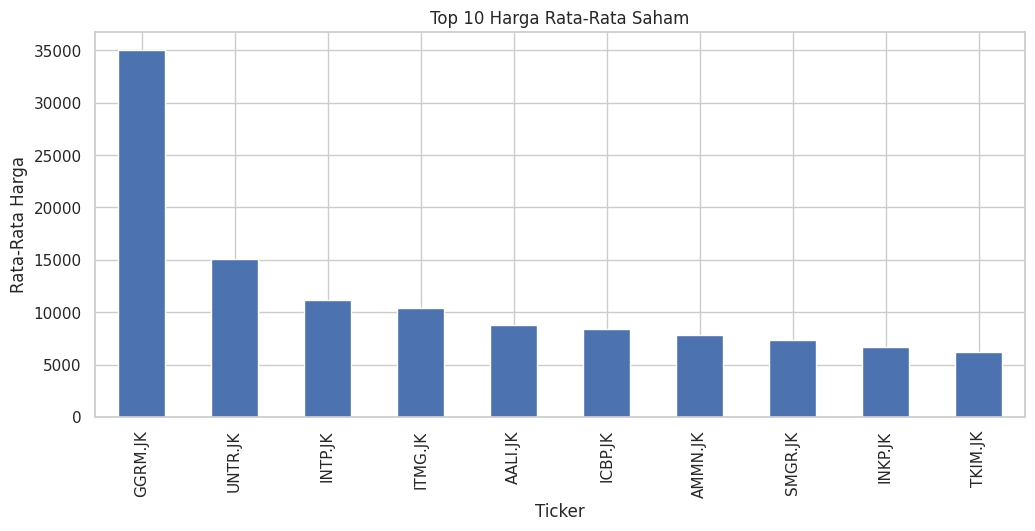

In [ ]:
# Membandingkan harga rata-rata antar saham
plt.figure(figsize=(12, 5))

average_price.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Harga Rata-Rata Saham")
plt.xlabel("Ticker")
plt.ylabel("Rata-Rata Harga")

plt.show()

Berdasarkan output di atas, grafik tersebut menunjukkan bahwa saham GGRM.JK lebih dari dua kali lipat saham UNTR.JK. Posisi 3-10 terlihat menurun landai, menandakan selisih antar saham tidak terlalu signifikan.

###**9. Analisis Pergerakan Harga Harian**

In [ ]:
# Menghitung daily return
clean_df["Return"] = (
    clean_df.groupby("Ticker")["Close"]
    .pct_change()
)

###**10. Distribusi Return Saham**
Return harian saham ($R_t$) mengukur perubahan persentase harga saham dari hari sebelumnya ke hari ini.

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

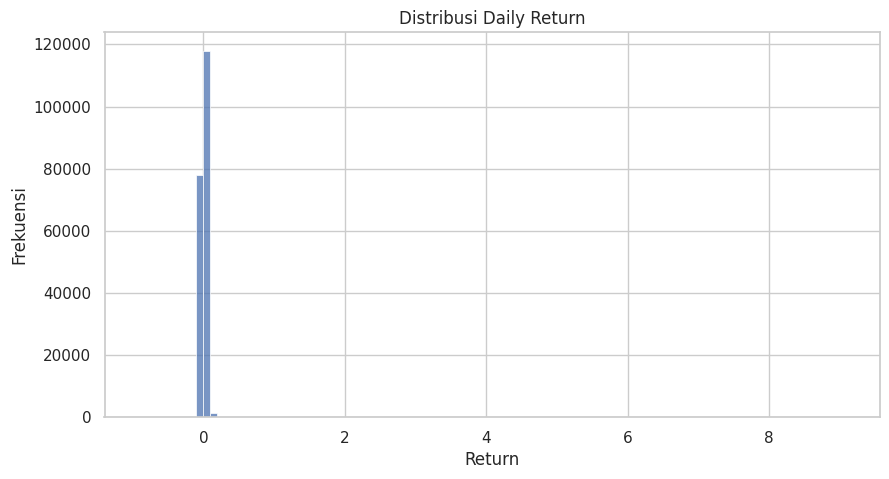

In [ ]:
# Visualisasi distribusi return
plt.figure(figsize=(10, 5))

sns.histplot(
    clean_df["Return"].dropna(),
    bins=100
)

plt.title("Distribusi Daily Return")
plt.xlabel("Return")
plt.ylabel("Frekuensi")

plt.show()

Berdasarkan output di atas, grafik mengindikasikan adanya outlier ekstrem yang kemungkinan berasal dari corporate action (stock split, dividen besar) atau anomali data

###**11. Visualisasi distribusi log return**

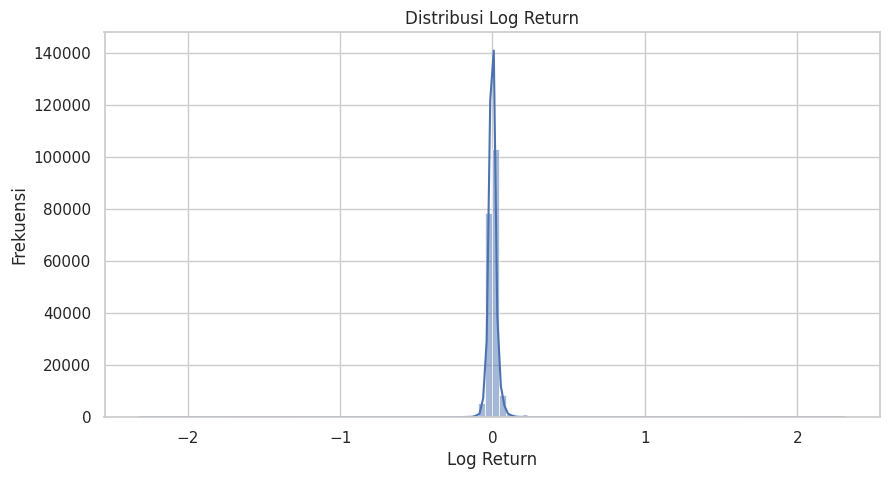

In [ ]:
clean_df["Log_Return"] = np.log(1 + clean_df["Return"])

# Visualisasi distribusi log return
plt.figure(figsize=(10, 5))

sns.histplot(
    clean_df["Log_Return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribusi Log Return")
plt.xlabel("Log Return")
plt.ylabel("Frekuensi")

plt.show()

###**12. Analisis Volalitas Saham**

Menghitung **rolling volatility** menggunakan standar deviasi dari return harian:

$$\sigma = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

In [ ]:
# Menghitung volatilitas 30 hari
clean_df["Volatility"] = (
    clean_df.groupby("Ticker")["Return"]
    .transform(lambda x: x.rolling(30).std())
)

###**13. Saham dengan Volalitas Tertinggi**

In [ ]:
# Mengidentifikasi saham paling fluktuatif
# Menghitung rata-rata volatilitas tiap saham
volatility_rank = (
    clean_df.groupby("Ticker")["Volatility"]
    .mean()
    .sort_values(ascending=False)
)

volatility_rank.head(10)

,Volatility
Ticker,
MAPI.JK,0.060991
PTMP.JK,0.053080
ARTO.JK,0.043304
GOTO.JK,0.037584
MBMA.JK,0.036298
BUMI.JK,0.036035
ESSA.JK,0.035786
INDY.JK,0.034809
MEDC.JK,0.032559


Berdasarkan output di atas, dapat dilihat bahwa MAPI.JK memiliki volalitas tertinggi sebesar 0.060991, sehingga menjadi saham yang paling fluktuatif, diikuti PTMP.JK dan ARTO.JK. Semakin tinggi nilai volalitas, semakin besar pergerakan harga saham dan risikonya

###**14. Visualisasi Volalitas Saham**

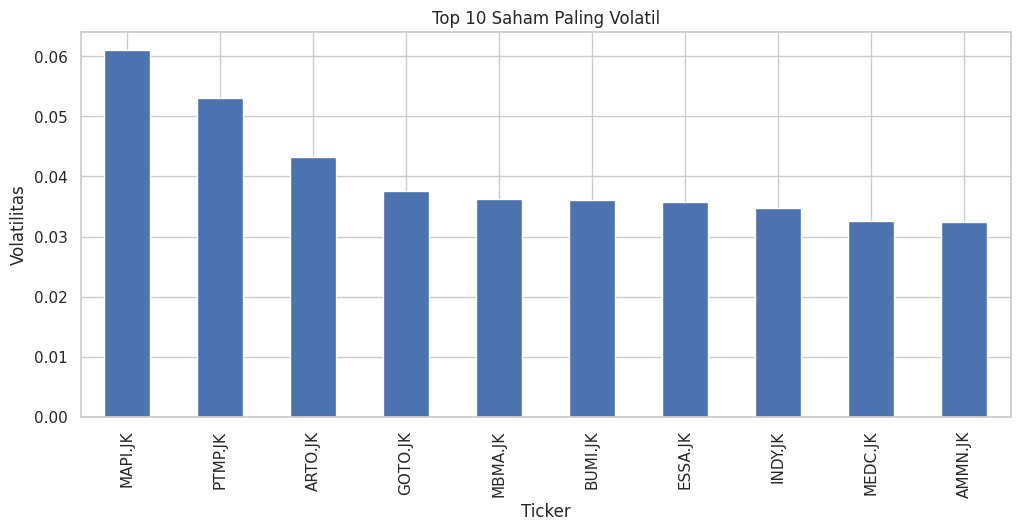

In [ ]:
# Membandingkan volatilitas antar saham
# Visualisasi top 10 volatilitas saham
plt.figure(figsize=(12, 5))

volatility_rank.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Saham Paling Volatil")
plt.xlabel("Ticker")
plt.ylabel("Volatilitas")

plt.show()

Berdasarkan hasil output di atas, sebagian besar saham LQ45 menunjukkan pola pergerakan harga yang fluktuatif selama periode 2015–2025. Beberapa saham memiliki volatilitas yang relatif tinggi, mengindikasikan risiko investasi yang lebih besar. Selain itu, distribusi return harian cenderung terpusat di sekitar nol dengan beberapa outlier ekstrem yang mencerminkan perubahan harga signifikan pada kondisi pasar tertentu.

# FEATURE ENGINEERING

In [ ]:
feature_df = clean_df.copy()

###**1. Penanganan Daily Return**

In [ ]:
feature_df["Return_Clipped"] = (
    feature_df.groupby("Ticker")["Return"]
    .transform(lambda x: x.clip(
        lower=x.quantile(0.01),
        upper=x.quantile(0.99)
    ))
)

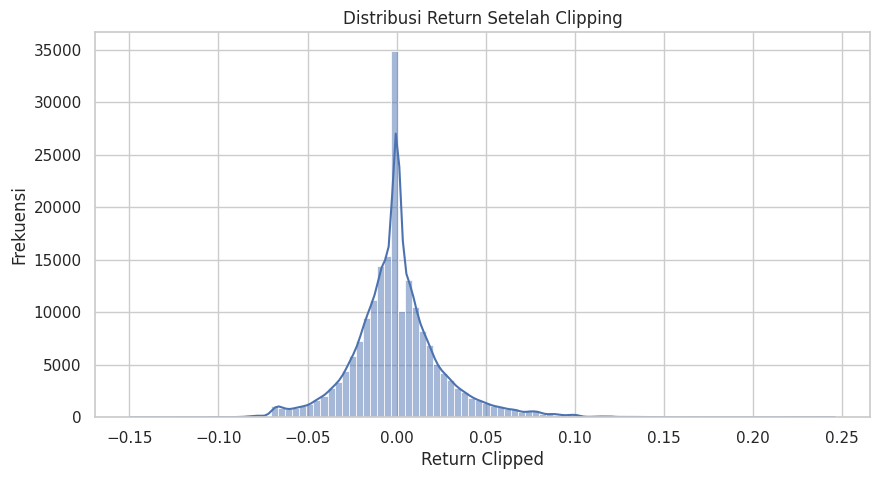

In [ ]:
# Visualisasi return setelah clipping
plt.figure(figsize=(10, 5))

sns.histplot(
    feature_df["Return_Clipped"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribusi Return Setelah Clipping")
plt.xlabel("Return Clipped")
plt.ylabel("Frekuensi")

plt.show()

Berdasarkan output di atas, distribusi menunjukkan bahwa data menjadi lebih terpusat di sekitar. Distribusi return tampak lebih stabil dengan bentuk menyerupai distribusi leptokurtic, yaitu memiliki puncak yang tinggi di tengah dan ekor distribusi masih relatif panjang. Kondisi ini umum ditemukan pada data keuangan karena pergerakan harga saham cenderung mengalami fluktuasi kecil pada sebagian besar waktu, namun sesekali terjadi perubahan harga yang besar.

Proses clipping berhasil meningkatkan kualitas dan kestabilan data tanpa menghilangkan keseluruhan observasi.

###**2. Log Return**

In [ ]:
feature_df["Log_Return"] = np.log(1 + feature_df["Return"])

###**3. Moving Average**

In [ ]:
# Moving Average 5 hari
feature_df["MA5"] = (
    feature_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(5).mean())
)
# Moving Average 7 hari
feature_df["MA7"] = (
    feature_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(7).mean())
)
# Moving Average 20 hari
feature_df["MA20"] = (
    feature_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(20).mean())
)
# Moving average 30 hari
feature_df["MA30"] = (
    feature_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(30).mean())
)

###**4. Rolling Volatility**

In [ ]:
# Menghitung volatilitas rolling 30 hari
feature_df["Volatility_30"] = (
    feature_df.groupby("Ticker")["Return"]
    .transform(lambda x: x.rolling(30).std())
)

###**5. Risk Category**

In [ ]:
volatility_df = (
    clean_df.groupby("Ticker")["Close"]
    .pct_change()
    .groupby(clean_df["Ticker"])
    .std()
    .reset_index()
)

volatility_df.columns = ["Ticker", "Volatility_Overall"]

q33 = volatility_df["Volatility_Overall"].quantile(0.33)
q66 = volatility_df["Volatility_Overall"].quantile(0.66)

print(f"Threshold Q33: {q33:.4f}")
print(f"Threshold Q66: {q66:.4f}")


def classify_risk(vol):
    if vol <= q33:
        return "Low"
    elif vol <= q66:
        return "Medium"
    else:
        return "High"


volatility_df["Risk_Category"] = volatility_df["Volatility_Overall"].apply(classify_risk)
print(volatility_df["Risk_Category"].value_counts())

# Merge Risk_Category ke feature_df
feature_df = feature_df.merge(
    volatility_df[["Ticker", "Risk_Category"]],
    on="Ticker",
    how="left"
)

Threshold Q33: 0.0253
Threshold Q66: 0.0301
Risk_Category
High      27
Low       26
Medium    26
Name: count, dtype: int64


###**6. Price Range**

In [ ]:
# Menghitung rentang harga harian
feature_df["Price_Range"] = (
    feature_df["High"] - feature_df["Low"]
)

###**6. Daily Price Change**

In [ ]:
# Menghitung perubahan harga harian
feature_df["Price_Change"] = (
    feature_df["Close"] - feature_df["Open"]
)

###**7. Lag Features**

In [ ]:
# Harga penutupan 1 hari sebelumnya
feature_df["Close_Lag_1"] = (
    feature_df.groupby("Ticker")["Close"]
    .shift(1)
)
# Harga penutupan 7 hari sebelumnya
feature_df["Close_Lag_7"] = (
    feature_df.groupby("Ticker")["Close"]
    .shift(7)
)

###**8. Momentum**

In [ ]:
# Momentum 7 hari
feature_df["Momentum_7"] = (
    feature_df.groupby("Ticker")["Close"]
    .diff(7)
)

###**9. Relative Volume**

In [ ]:
# Relative volume terhadap rata-rata 30 hari
feature_df["Relative_Volume"] = (
    feature_df["Volume"] /
    feature_df.groupby("Ticker")["Volume"]
    .transform(lambda x: x.rolling(30).mean())
)

###**10. RSI (Relative Strength Index) 14 hari**

In [ ]:
rsi_window = 14

delta = feature_df.groupby('Ticker')['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.groupby(feature_df['Ticker']).transform(lambda x: x.ewm(com=rsi_window - 1, adjust=False).mean())

avg_loss = loss.groupby(feature_df['Ticker']).transform(lambda x: x.ewm(com=rsi_window - 1, adjust=False).mean())

rs = avg_gain / avg_loss
feature_df[f'RSI_{rsi_window}'] = 100 - (100 / (1 + rs))

###**11. EMA (Exponential Moving Averafe) 9, 21, 50 hari**

In [ ]:
for window in [9, 21, 50]:
    feature_df[f'EMA_{window}'] = (
        feature_df.groupby('Ticker')['Close']
        .transform(lambda x: x.ewm(span=window, adjust=False).mean())
    )

###**11. MACD - Moving Average Convergence Divergence**

In [ ]:
macd_fast, macd_slow, macd_signal = 12, 26, 9

exp_fast = feature_df.groupby("Ticker")["Close"].transform(
    lambda x: x.ewm(span=macd_fast, adjust=False).mean()
)
exp_slow = feature_df.groupby("Ticker")["Close"].transform(
    lambda x: x.ewm(span=macd_slow, adjust=False).mean()
)

feature_df["MACD"] = exp_fast - exp_slow
feature_df["Signal_Line"] = feature_df.groupby("Ticker")["MACD"].transform(
    lambda x: x.ewm(span=macd_signal, adjust=False).mean()
)
feature_df["MACD_Hist"] = feature_df["MACD"] - feature_df["Signal_Line"]

###**12. Bollinger Bands**


In [ ]:
bb_std = 2.0

feature_df["STD_BB"] = (
    feature_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(window=20).std())
)
feature_df["Upper_BB"] = feature_df["MA20"] + (feature_df["STD_BB"] * bb_std)
feature_df["Lower_BB"] = feature_df["MA20"] - (feature_df["STD_BB"] * bb_std)

In [ ]:
required_cols = [
    "Return", "Return_Clipped", "Log_Return",
    "MA5", "MA7", "MA20", "MA30", "Volatility_30",
    "Close_Lag_1", "Close_Lag_7", "Momentum_7",
    "Relative_Volume", "RSI_14",
    "EMA_9", "EMA_21", "EMA_50",
    "MACD", "Signal_Line", "MACD_Hist",
    "STD_BB", "Upper_BB", "Lower_BB"
]

feature_df = feature_df.dropna(subset=required_cols).reset_index(drop=True)

In [ ]:
# Ringkasan dataset final
print(f"Shape final dataset: {feature_df.shape}")
print(f"Jumlah saham unik  : {feature_df['Ticker'].nunique()}")
print(f"Periode data       : {feature_df['Date'].min()} s/d {feature_df['Date'].max()}")
print(f"\nDistribusi Risk Category:\n{feature_df['Risk_Category'].value_counts()}")

Shape final dataset: (194872, 33)
Jumlah saham unik  : 79
Periode data       : 2015-02-13 00:00:00 s/d 2025-12-30 00:00:00

Distribusi Risk Category:
Risk_Category
Medium    68047
Low       67899
High      58926
Name: count, dtype: int64


In [ ]:
# Menampilkan beberapa kolom hasil feature engineering
preview_cols = [
    "Date", "Ticker", "Close", "Risk_Category",
    "Return", "Return_Clipped", "Log_Return",
    "MA5", "MA7", "MA20", "MA30", "Volatility_30",
    "Price_Range", "Price_Change",
    "Close_Lag_1", "Close_Lag_7", "Momentum_7",
    "Relative_Volume",
    "RSI_14",
    "EMA_9", "EMA_21", "EMA_50",
    "MACD", "Signal_Line", "MACD_Hist",
    "STD_BB", "Upper_BB", "Lower_BB"
]

In [ ]:
# Menampilkan dataset final
print("\nPreview 5 baris pertama:")
print(feature_df[preview_cols].head())


Preview 5 baris pertama:
        Date   Ticker         Close Risk_Category    Return  Return_Clipped  \
0 2015-02-13  AALI.JK  16898.824219           Low  0.006883        0.006883   
1 2015-02-16  AALI.JK  16502.753906           Low -0.023438       -0.023438   
2 2015-02-17  AALI.JK  16634.775391           Low  0.008000        0.008000   
3 2015-02-18  AALI.JK  16651.279297           Low  0.000992        0.000992   
4 2015-02-20  AALI.JK  16486.251953           Low -0.009911       -0.009911   

   Log_Return           MA5           MA7          MA20  ...     RSI_14  \
0    0.006860  16641.378125  16681.928153  16056.356348  ...  58.899855   
1   -0.023717  16614.973828  16733.793527  16072.858984  ...  53.138628   
2    0.007968  16677.683984  16620.631417  16095.962695  ...  54.728219   
3    0.000992  16694.187109  16622.989118  16130.618311  ...  54.934019   
4   -0.009960  16634.776953  16646.564453  16162.798486  ...  52.370374   

          EMA_9        EMA_21        EMA_50     

In [ ]:
# Menyimpan dataset hasil feature engineering
feature_df.to_csv(
    "lq45_feature_engineering.csv",
    index=False
)